
Load Datasets
  Sold : 447,769 rows  |  87 columns
  List : 615,316 rows  |  70 columns

STEP 1 — IQR OUTLIER DETECTION

  [Sold] IQR bounds and flag counts:
  Field                               Q1           Q3          IQR        Lower        Upper    Flagged
  ------------------------- ------------ ------------ ------------ ------------ ------------ ----------
  ClosePrice                   575,000.0  1,300,000.0    725,000.0   -512,500.0  2,387,500.0     33,477
  LivingArea                     1,248.0      2,224.0        976.0       -216.0      3,688.0     19,568
  DaysOnMarket                       8.0         48.0         40.0        -52.0        108.0     34,144

  any_outlier_flag          (any of the above)  →  70,296 rows flagged (15.70%)

  [List] IQR bounds and flag counts:
  Field                               Q1           Q3          IQR        Lower        Upper    Flagged
  ------------------------- ------------ ------------ ------------ ------------ ------------ -----

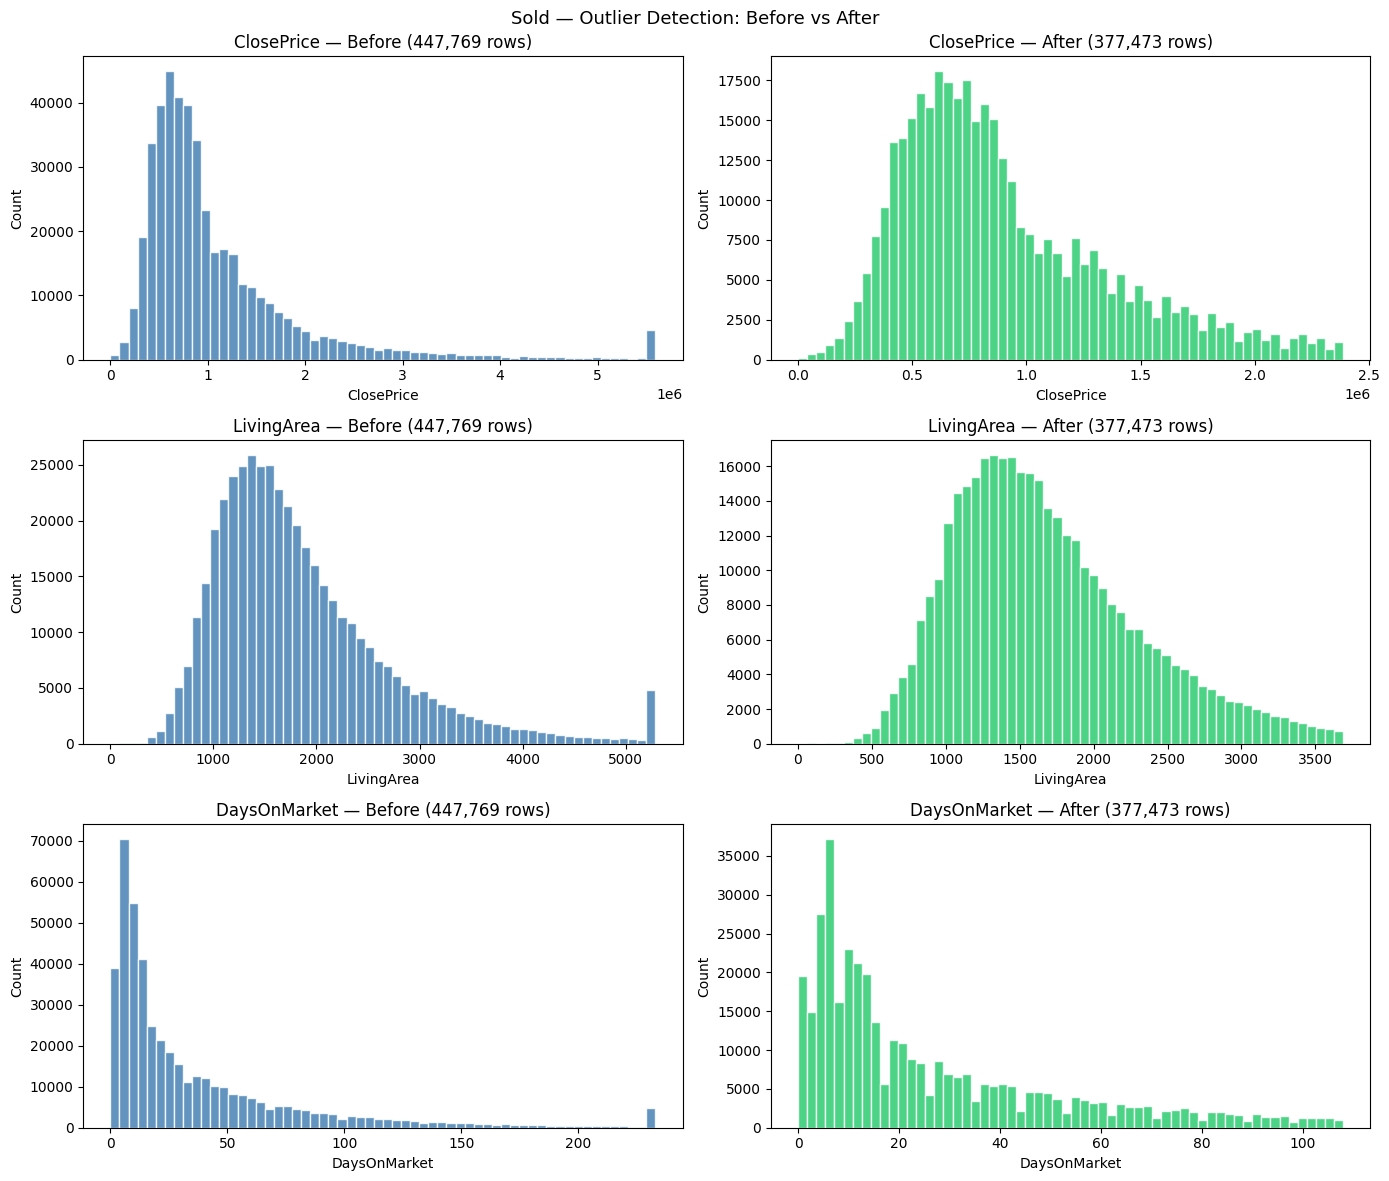

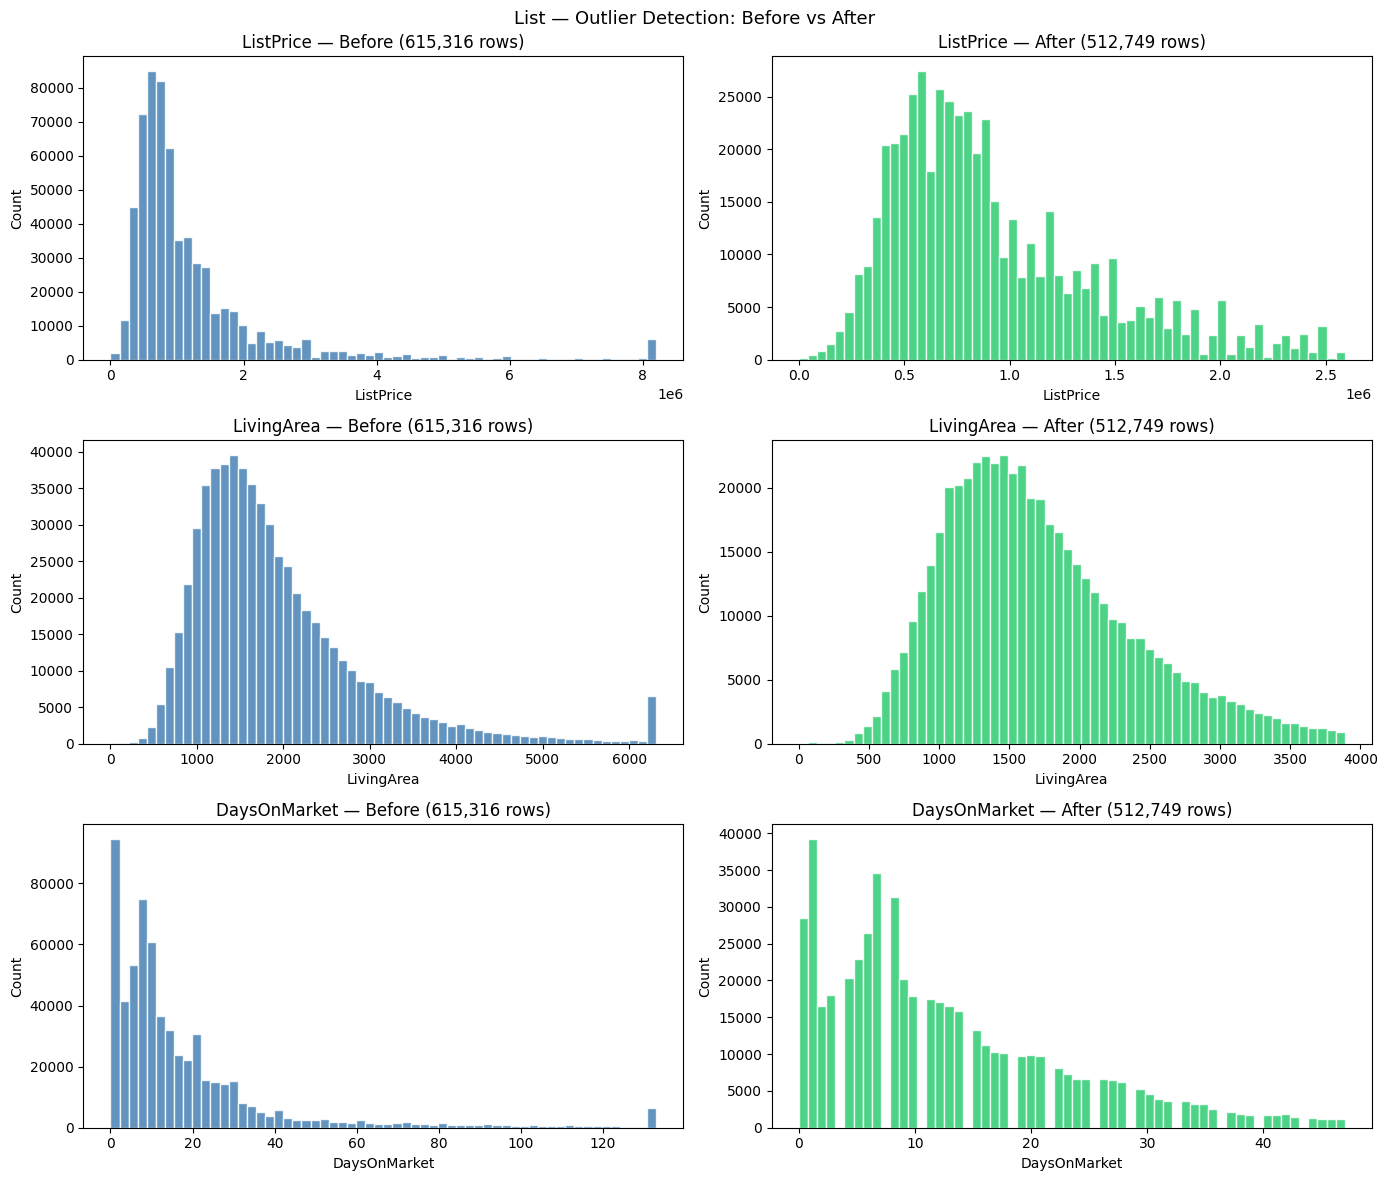


STEP 4 — SAVE OUTPUTS
  Saved: all_sold_flagged.csv                447,769 rows  |  91 columns
  Saved: all_sold_filtered.csv               377,473 rows  |  91 columns
  Saved: all_list_flagged.csv                615,316 rows  |  74 columns
  Saved: all_list_filtered.csv               512,749 rows  |  74 columns

STEP 5 — FINAL SUMMARY

  Dataset               Rows Before   Rows After    Removed  Removed %
  -------------------- ------------ ------------ ---------- ----------
  Sold                      447,769      377,473     70,296     15.70%
  List                      615,316      512,749    102,567     16.67%

  Median value comparison:
  Field                       Sold Before    Sold After   List Before    List After
  ------------------------- ------------- ------------- ------------- -------------
  ClosePrice/ListPrice           $825,000      $787,500      $849,000      $798,000
  LivingArea                       $1,646        $1,572        $1,673        $1,587
  DaysOnMark

In [3]:
import os
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# =========================================================================
# Configuration
# =========================================================================

PATH         = r'C:\Users\lidon\Desktop\2026spring\IDX_MLS_Analytics'
SOLD_INPUT   = os.path.join(PATH, 'sold_residential_features_enriched.csv')
LIST_INPUT   = os.path.join(PATH, 'list_residential_features_enriched.csv')
DTYPE_SPEC   = {'PostalCode': str, 'ListingKey': str}

# Fields to apply IQR outlier detection
# Sold: ClosePrice, LivingArea, DaysOnMarket
# List: ListPrice,  LivingArea, DaysOnMarket
SOLD_FIELDS = ['ClosePrice', 'LivingArea', 'DaysOnMarket']
LIST_FIELDS = ['ListPrice',  'LivingArea', 'DaysOnMarket']

# =========================================================================
# Helper: section header
# =========================================================================

def section(title):
    print()
    print("=" * 70)
    print(title)
    print("=" * 70)

# =========================================================================
# Load datasets
# =========================================================================

section("Load Datasets")

sold = pd.read_csv(SOLD_INPUT, dtype=DTYPE_SPEC, low_memory=False)
lst  = pd.read_csv(LIST_INPUT, dtype=DTYPE_SPEC, low_memory=False)

print(f"  Sold : {len(sold):,} rows  |  {sold.shape[1]} columns")
print(f"  List : {len(lst):,} rows  |  {lst.shape[1]} columns")

# =========================================================================
# STEP 1 — IQR Outlier Detection
# For each field:
#   - Compute Q1, Q3, IQR
#   - Lower bound = Q1 - 1.5 * IQR
#   - Upper bound = Q3 + 1.5 * IQR
#   - Create a boolean flag column: True = outlier
#   - Do NOT delete any rows here
# =========================================================================

section("STEP 1 — IQR OUTLIER DETECTION")

def add_iqr_flags(df, fields, label):
    """
    Add one boolean flag column per field using the IQR method.
    Rows are flagged but never deleted at this stage.
    Returns the dataframe with flag columns added.
    """
    print(f"\n  [{label}] IQR bounds and flag counts:")
    print(f"  {'Field':<25} {'Q1':>12} {'Q3':>12} {'IQR':>12} "
          f"{'Lower':>12} {'Upper':>12} {'Flagged':>10}")
    print(f"  {'-'*25} {'-'*12} {'-'*12} {'-'*12} "
          f"{'-'*12} {'-'*12} {'-'*10}")

    df = df.copy()
    flag_cols = []

    for field in fields:
        if field not in df.columns:
            print(f"  {field:<25} not found — skipped")
            continue

        col  = df[field].dropna()
        q1   = col.quantile(0.25)
        q3   = col.quantile(0.75)
        iqr  = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        flag_name = f"{field}_outlier_flag"
        df[flag_name] = (
            df[field].notna() &
            ((df[field] < lower) | (df[field] > upper))
        )
        flag_cols.append(flag_name)
        flagged = df[flag_name].sum()

        print(f"  {field:<25} {q1:>12,.1f} {q3:>12,.1f} {iqr:>12,.1f} "
              f"{lower:>12,.1f} {upper:>12,.1f} {flagged:>10,}")

    # Combined flag: True if ANY field is flagged
    if flag_cols:
        df['any_outlier_flag'] = df[flag_cols].any(axis=1)
        total_flagged = df['any_outlier_flag'].sum()
        print(f"\n  {'any_outlier_flag':<25} "
              f"(any of the above)  →  {total_flagged:,} rows flagged "
              f"({total_flagged/len(df)*100:.2f}%)")

    return df, flag_cols

sold, sold_flag_cols = add_iqr_flags(sold, SOLD_FIELDS, 'Sold')
lst,  list_flag_cols = add_iqr_flags(lst,  LIST_FIELDS, 'List')

# =========================================================================
# STEP 2 — Before / After comparison
# Compare row counts and median values before and after filtering
# =========================================================================

section("STEP 2 — BEFORE / AFTER COMPARISON")

def compare_before_after(df, fields, label):
    clean = df[~df['any_outlier_flag']]

    print(f"\n  [{label}]")
    print(f"  {'':25} {'Before':>12} {'After':>12} {'Removed':>10}")
    print(f"  {'-'*25} {'-'*12} {'-'*12} {'-'*10}")
    print(f"  {'Row count':<25} {len(df):>12,} {len(clean):>12,} "
          f"{len(df)-len(clean):>10,}")

    for field in fields:
        if field not in df.columns:
            continue
        med_before = df[field].median()
        med_after  = clean[field].median()
        print(f"  {field+' (median)':<25} "
              f"{med_before:>12,.0f} {med_after:>12,.0f} "
              f"{'':>10}")

    return clean

sold_filtered = compare_before_after(sold, SOLD_FIELDS, 'Sold')
list_filtered = compare_before_after(lst,  LIST_FIELDS, 'List')

# =========================================================================
# STEP 3 — Distribution charts (before vs after)
# =========================================================================

section("STEP 3 — DISTRIBUTION CHARTS")

def plot_distributions(df_before, df_after, fields, label):
    n_fields = len([f for f in fields if f in df_before.columns])
    if n_fields == 0:
        return

    fig, axes = plt.subplots(n_fields, 2,
                             figsize=(14, 4 * n_fields))
    fig.suptitle(f'{label} — Outlier Detection: Before vs After',
                 fontsize=13)

    if n_fields == 1:
        axes = [axes]

    row = 0
    for field in fields:
        if field not in df_before.columns:
            continue

        ax_before = axes[row][0]
        ax_after  = axes[row][1]

        clip = df_before[field].quantile(0.99)
        before_clipped = df_before[field].clip(upper=clip)
        after_clipped  = df_after[field].clip(upper=clip)

        ax_before.hist(before_clipped.dropna(), bins=60,
                       color='steelblue', edgecolor='white', alpha=0.85)
        ax_before.set_title(f'{field} — Before ({len(df_before):,} rows)')
        ax_before.set_xlabel(field)
        ax_before.set_ylabel('Count')

        ax_after.hist(after_clipped.dropna(), bins=60,
                      color='#2ecc71', edgecolor='white', alpha=0.85)
        ax_after.set_title(f'{field} — After ({len(df_after):,} rows)')
        ax_after.set_xlabel(field)
        ax_after.set_ylabel('Count')

        row += 1

    plt.tight_layout()
    plt.show()

plot_distributions(sold, sold_filtered, SOLD_FIELDS, 'Sold')
plot_distributions(lst,  list_filtered, LIST_FIELDS, 'List')

# =========================================================================
# STEP 4 — Save outputs
# Two versions per dataset:
#   *_flagged  : all rows retained, with flag columns added
#   *_filtered : only clean rows (any_outlier_flag == False)
# =========================================================================

section("STEP 4 — SAVE OUTPUTS")

outputs = {
    'all_sold_flagged.csv':    sold,
    'all_sold_filtered.csv':   sold_filtered,
    'all_list_flagged.csv':    lst,
    'all_list_filtered.csv':   list_filtered,
}

for filename, df in outputs.items():
    path = os.path.join(PATH, filename)
    df.to_csv(path, index=False, encoding='utf-8')
    print(f"  Saved: {filename:<35} {len(df):,} rows  |  {df.shape[1]} columns")

# =========================================================================
# STEP 5 — Final summary table
# =========================================================================

section("STEP 5 — FINAL SUMMARY")

print(f"\n  {'Dataset':<20} {'Rows Before':>12} {'Rows After':>12} "
      f"{'Removed':>10} {'Removed %':>10}")
print(f"  {'-'*20} {'-'*12} {'-'*12} {'-'*10} {'-'*10}")

for label, before, after in [
    ('Sold', sold, sold_filtered),
    ('List', lst,  list_filtered),
]:
    removed = len(before) - len(after)
    print(f"  {label:<20} {len(before):>12,} {len(after):>12,} "
          f"{removed:>10,} {removed/len(before)*100:>9.2f}%")

print(f"\n  Median value comparison:")
print(f"  {'Field':<25} {'Sold Before':>13} {'Sold After':>13} "
      f"{'List Before':>13} {'List After':>13}")
print(f"  {'-'*25} {'-'*13} {'-'*13} {'-'*13} {'-'*13}")

compare_fields = [
    ('ClosePrice',  'ListPrice'),
    ('LivingArea',  'LivingArea'),
    ('DaysOnMarket','DaysOnMarket'),
]

for sold_field, list_field in compare_fields:
    sb = f"${sold['ClosePrice' if sold_field == 'ClosePrice' else sold_field].median():,.0f}" \
         if sold_field in sold.columns else 'N/A'
    sa = f"${sold_filtered['ClosePrice' if sold_field == 'ClosePrice' else sold_field].median():,.0f}" \
         if sold_field in sold_filtered.columns else 'N/A'
    lb = f"${lst[list_field].median():,.0f}" \
         if list_field in lst.columns else 'N/A'
    la = f"${list_filtered[list_field].median():,.0f}" \
         if list_field in list_filtered.columns else 'N/A'

    display_field = sold_field if sold_field == list_field else f"{sold_field}/{list_field}"
    print(f"  {display_field:<25} {sb:>13} {sa:>13} {lb:>13} {la:>13}")

print("\n" + "=" * 70)
print("WEEK 7 OUTLIER DETECTION COMPLETE")
print("=" * 70)